In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 

In [2]:
df = pd.read_csv('13-car_evaluation.csv')

In [3]:
df.head()

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   vhigh    1727 non-null   object
 1   vhigh.1  1727 non-null   object
 2   2        1727 non-null   object
 3   2.1      1727 non-null   object
 4   small    1727 non-null   object
 5   low      1727 non-null   object
 6   unacc    1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [5]:
# kolanlarimizin ismi acikalamdi gibi gozukmuyor bundan dolayi ilk bunu duzeltiliyorum

In [6]:
new_columns = ['buying','maint','doors','persons','lug_boot','safety','class']

In [7]:
df.columns = new_columns

In [8]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   object
 3   persons   1727 non-null   object
 4   lug_boot  1727 non-null   object
 5   safety    1727 non-null   object
 6   class     1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [10]:
for col in df.columns:
    print(df[col].value_counts())

buying
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
maint
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
doors
3        432
4        432
5more    432
2        431
Name: count, dtype: int64
persons
4       576
more    576
2       575
Name: count, dtype: int64
lug_boot
med      576
big      576
small    575
Name: count, dtype: int64
safety
med     576
high    576
low     575
Name: count, dtype: int64
class
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [11]:
# vermize baktigimda class -> target verable , doors,person,rest -> categorial 

In [12]:
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

In [13]:
# verimizde kayip veri yoktur

In [14]:
df['doors'].unique()

array(['2', '3', '4', '5more'], dtype=object)

In [15]:
# more burda bizi bozuyor bunu duzelticem

In [16]:
# 5more gordugum her yere 5 koyucam baska bir seyde yapilabilir ama ben bunu tercih ediyorum

In [17]:
df['doors'] = df['doors'].replace('5more','5')

In [18]:
df['doors'].unique()

array(['2', '3', '4', '5'], dtype=object)

In [19]:
df['doors'] = df['doors'].astype(int)

In [20]:
df['persons'].unique()

array(['2', '4', 'more'], dtype=object)

In [21]:
df['persons'] = df['persons'].replace('more','5')

In [22]:
# 5 kisiklikten fazla araba cok fazla yok ondan dolayi more 5 ile degistirmeye karar verdim

In [23]:
df['persons'] = df['persons'].astype(int)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   int64 
 3   persons   1727 non-null   int64 
 4   lug_boot  1727 non-null   object
 5   safety    1727 non-null   object
 6   class     1727 non-null   object
dtypes: int64(2), object(5)
memory usage: 94.6+ KB


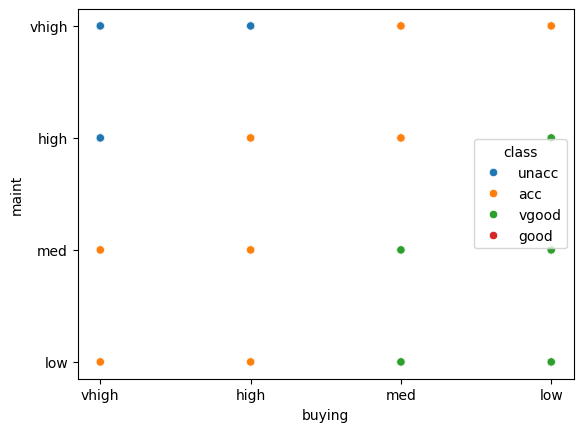

In [26]:
sns.scatterplot(x=df['buying'],y=df['maint'],hue=df['class'])
plt.show()

In [27]:
# kategorik degerler oldugu icin boyle kumeli bir sekilde duruyor vermizde 

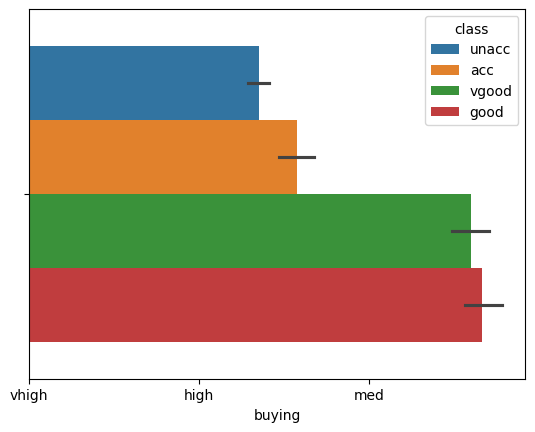

In [29]:
sns.barplot(x=df['buying'],hue=df['class'])
plt.show()

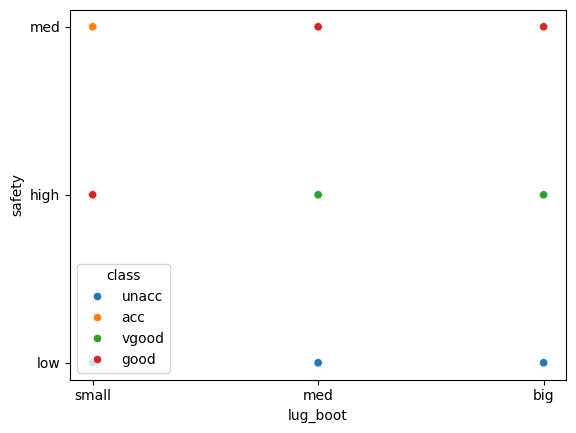

In [32]:
sns.scatterplot(x=df['lug_boot'],y=df['safety'],hue=df['class'])
plt.show()

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1727 non-null   object
 1   maint     1727 non-null   object
 2   doors     1727 non-null   int64 
 3   persons   1727 non-null   int64 
 4   lug_boot  1727 non-null   object
 5   safety    1727 non-null   object
 6   class     1727 non-null   object
dtypes: int64(2), object(5)
memory usage: 94.6+ KB


In [34]:
X  = df.drop('class',axis=1)
y  = df['class']

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=15)

In [37]:
X_train.head()

,buying,maint,doors,persons,lug_boot,safety
680,high,med,3,2,big,low
765,high,low,2,4,small,med
722,high,med,4,5,med,low
665,high,med,2,5,small,low
986,med,high,2,4,big,low


In [39]:
X_train.shape

(1295, 6)

In [40]:
# ENCODING 

In [41]:
# ordinal encoding yapmak daha mantikli cunku kategori degistikce degeride artiyor yada azaliyor buna gore numaralandirip verimizzi islenebilir hale getirelim

In [42]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import  Pipeline

In [54]:
categorical_cols = ['buying', 'maint', 'lug_boot', 'safety']
numerical_cols = ['doors', 'persons']

ordinal_encoder = OrdinalEncoder(categories=[
    ['low', 'med', 'high', 'vhigh'],
    ['low', 'med', 'high', 'vhigh'],
    ['small', 'med', 'big'],
    ['low', 'med', 'high'],
])

# preprocessor yukaridaki yerin daha kisa versiyonu bir cok farkli kolonumuz oldugunda asagidaki kod cok isimize yarar 
preprocessor = ColumnTransformer(transformers=[
    ('istedigimiz bir isim', ordinal_encoder, categorical_cols),
], remainder='passthrough') # eger vermizde diger seylerin degismesini istemiyorsa passthrough kismini kesinlikle yazmaliyiz

X_train_transformation = preprocessor.fit_transform(X_train)
X_test_transformation = preprocessor.transform(X_test)

In [49]:
for col in categorial_cols:
    print(df[col].value_counts())

buying
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
maint
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64
lug_boot
med      576
big      576
small    575
Name: count, dtype: int64
safety
med     576
high    576
low     575
Name: count, dtype: int64


In [45]:
# yukarida yapmiz ordinal encod islemini daha kisa bir sekilde yapabiliriz 

In [55]:
pd.DataFrame(X_train_transformation)

,0,1,2,3,4,5
0,2.0,1.0,2.0,0.0,3.0,2.0
1,2.0,0.0,0.0,1.0,2.0,4.0
2,2.0,1.0,1.0,0.0,4.0,5.0
3,2.0,1.0,0.0,0.0,2.0,5.0
4,1.0,2.0,2.0,0.0,2.0,4.0
...,...,...,...,...,...,...
1290,2.0,1.0,0.0,2.0,2.0,5.0
1291,3.0,2.0,1.0,1.0,3.0,5.0
1292,3.0,0.0,2.0,1.0,4.0,2.0
1293,2.0,2.0,2.0,1.0,5.0,5.0


In [56]:
pd.DataFrame(X_test_transformation)[4].unique()

array([4., 5., 2., 3.])

In [57]:
# goruldugu uzere kapi sayimiz istedigimiz sekilde vermizi yansimistir 

In [58]:
pd.DataFrame(X_test_transformation)[1].unique()

array([1., 0., 3., 2.])

In [59]:
from sklearn.tree import DecisionTreeClassifier

In [64]:
tree_model = DecisionTreeClassifier(criterion='gini',max_depth=3,random_state=0)
tree_model.fit(X_train_transformation,y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [62]:
# 1. CRITERION='GINI' (Varsayılan / Default)
# ------------------------------------------------------------------------------
# Nerede/Ne Zaman Kullanılır:
# - Büyük veri setlerinde hızlıca model kurmak istiyorsan.
# - Matematiksel olarak logaritma hesabı yapmadığı için DAHA HIZLI çalışır.
# - Pratik çalışmalarda ve genel ilk denemelerde (baseline model) ilk tercihtir.

# 2. CRITERION='ENTROPY' (Bilgi Kazancı / Information Gain)
# ------------------------------------------------------------------------------
# Nerede/Ne Zaman Kullanılır:
# - Sınıfların veri içindeki belirsizliğini ve "saf bilgisini" daha hassas 
#   ölçmek istediğinde.
# - Logaritmik hesaplama yaptığı için 'gini'ye kıyasla BİRAZ DAHA YAVAŞ çalışır.
# - Gini ile kurduğun modelin sonuçlarını bir tık daha optimize etmek ve 
#   farklı dallanma alternatiflerini denemek istediğinde tercih edilir.

# ÖZET NOT: 
# İkisi arasındaki başarı (accuracy) farkı genelde çok çok azdır. 
# Hız gerekiyorsa 'gini', teorik belirsizlik analizi ağır basıyorsa 'entropy' seçilir.

In [65]:
y_pred = tree_model.predict(X_test_transformation)

In [66]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

In [67]:
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

         acc       0.51      0.47      0.49        93
        good       0.00      0.00      0.00        19
       unacc       0.86      0.97      0.91       305
       vgood       0.00      0.00      0.00        15

    accuracy                           0.79       432
   macro avg       0.34      0.36      0.35       432
weighted avg       0.72      0.79      0.75       432

[[ 44   0  49   0]
 [ 19   0   0   0]
 [  8   0 297   0]
 [ 15   0   0   0]]
0.7893518518518519


C:\Users\PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PC\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [68]:
# vermizde good ve very good kisminda tahimlerimiz kotu 
# genel accuracy score fena degil ama iyilestirmemiz gerekiyor

<Figure size 1200x800 with 0 Axes>

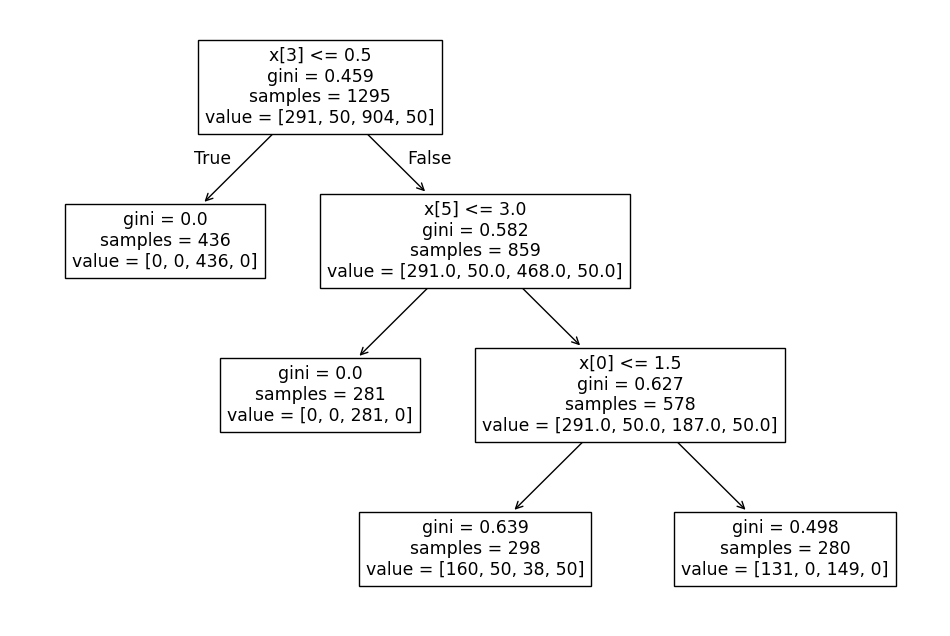

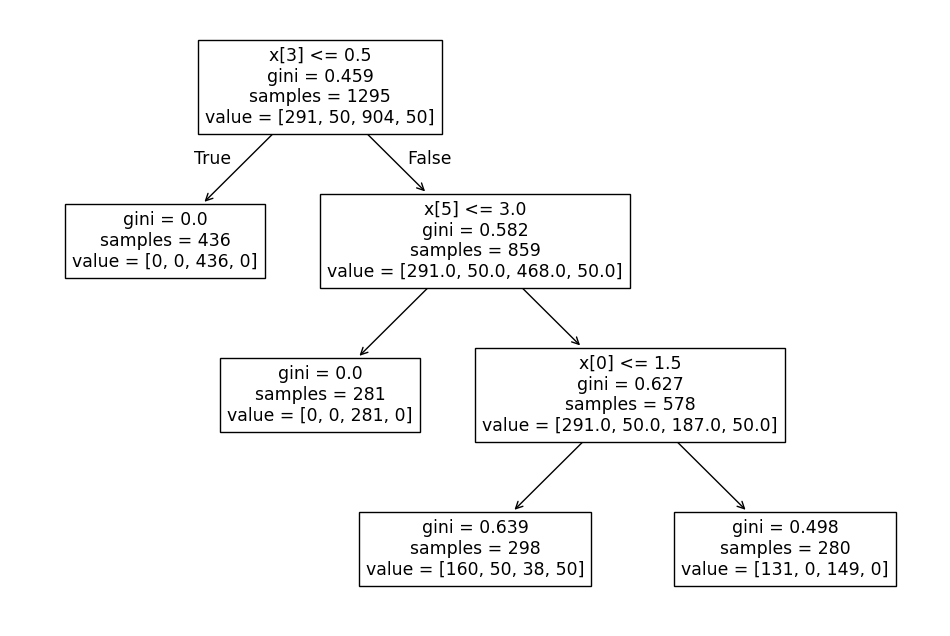

In [71]:
plt.figure(figsize=(12,8))
from sklearn import tree
tree.plot_tree(tree_model.fit(X_train_transformation,y_train))
plt.show()

In [72]:
# HYPERPARAMETRE

In [73]:
param = {
    'criterion':['gini','entrop','log_loss'],
    'splitter' : ['best','random'],
    'max_depth': [1,2,3,4,5,15,None],
    'max_features':['sqrt','log2',None]
}

In [74]:
from sklearn.model_selection import GridSearchCV

In [75]:
grid = GridSearchCV(estimator=DecisionTreeClassifier(),param_grid=param,cv=5,scoring='accuracy')

In [76]:
import warnings
warnings.filterwarnings('ignore')
grid.fit(X_train_transformation,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entrop', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5, 15, None],
                         'max_features': ['sqrt', 'log2', None],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [77]:
grid.best_params_

{'criterion': 'gini',
 'max_depth': 15,
 'max_features': None,
 'splitter': 'best'}

In [78]:
grid.best_score_

np.float64(0.9691119691119692)

In [79]:
y_pred = grid.predict(X_test_transformation)

In [80]:
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.9837962962962963
[[ 91   0   1   1]
 [  3  16   0   0]
 [  2   0 303   0]
 [  0   0   0  15]]
              precision    recall  f1-score   support

         acc       0.95      0.98      0.96        93
        good       1.00      0.84      0.91        19
       unacc       1.00      0.99      1.00       305
       vgood       0.94      1.00      0.97        15

    accuracy                           0.98       432
   macro avg       0.97      0.95      0.96       432
weighted avg       0.98      0.98      0.98       432



In [81]:
# goruldugu uzere suan good be very good kismini cokta daha iyi hale getirdik 

In [82]:
tree_model_new = DecisionTreeClassifier(criterion='entropy',max_depth=None,max_features=None,splitter='best')

In [83]:
tree_model_new.fit(X_train_transformation,y_train)
y_pred = tree_model_new.predict(X_test_transformation)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.9791666666666666
[[ 91   0   1   1]
 [  3  16   0   0]
 [  4   0 301   0]
 [  0   0   0  15]]
              precision    recall  f1-score   support

         acc       0.93      0.98      0.95        93
        good       1.00      0.84      0.91        19
       unacc       1.00      0.99      0.99       305
       vgood       0.94      1.00      0.97        15

    accuracy                           0.98       432
   macro avg       0.97      0.95      0.96       432
weighted avg       0.98      0.98      0.98       432



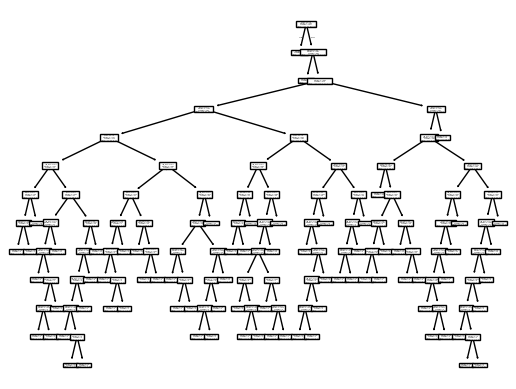

In [88]:
column_names = categorial_cols + numerical_cols
tree.plot_tree(tree_model_new.fit(X_train_transformation,y_train),feature_names=column_names)
plt.show()